# Physics-Informed Neural Networks Former (PINNsFormer) for 4D Hodgkin-Huxley Dynamics

This notebook implements the **PINNsFormer** architecture, a Transformer-based framework designed for Physics-Informed Neural Networks (PINNs), to solve the stiff ordinary differential equations (ODEs) of the **4-dimensional Hodgkin-Huxley (HH) neuron model**.

### Gating Kinetics & Membrane Potential
The state vector of the system is given by $\mathbf{x}(t) = [V(t), m(t), h(t), n(t)]^T \in \mathbb{R}^4$. 

Standard PINNs suffer from **spectral bias** on high-frequency stiff upstrokes. PINNsFormer resolves this using:
1.  **Dual-Timescale Trajectories**: Fine-scale path (resolves fast action potentials, $V$ and $m$) and Coarse-scale path (captures slow recovery decays, $h$ and $n$).
2.  **Wavelet Activations**: Custom periodic activations to capture high-frequency components locally.
3.  **Temporal Causality Masking**: Causal weighting to enforce learning earlier step states before later ones.
4.  **NTK Weight Balancing**: Dynamically balances the physics residuals, boundary conditions, and supervised data losses using trace gradients.


In [19]:
Threads.nthreads()


8

In [20]:
using LinearAlgebra
LinearAlgebra.BLAS.set_num_threads(1)  # Prevents CPU thread oversubscription thrashing


In [21]:
using Plots
using Flux                  # Neural network framework
using NNlib                 # Activation functions, softmax, etc.
using LinearAlgebra         # Matrix operations
using Statistics            # Mean, std
using Random
using ForwardDiff           # Automatic differentiation
using Zygote
using Optim
using Printf
using Serialization


## Section 2: Ground-Truth Data Verification

We load the synthetic data generated using the high-order stiff `RadauIIA5` ODE solver (dense sampling at $0.01\,\text{ms}$ intervals). The resting potential starts at $-65.0\,\text{mV}$ and a current stimulus $I_{\text{ext}} = 10.0\,\mu\text{A/cm}^2$ is applied between $2.0\,\text{ms}$ and $30.0\,\text{ms}$ to generate a single action potential upstroke and refractory recovery period.


In [22]:
using CSV, DataFrames

# Load synthetic dataset (using robust relative paths)
file_path = joinpath("..", "Synthetic_Data", "HH_ground_truth_synthetic_data.csv")
HH_data = CSV.read(file_path, DataFrame)
first(HH_data, 5)


Row,t,V,m,h,n
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.0529,0.5961,0.3177
2,0.01,-65.0,0.0529013,0.5961,0.3177
3,0.02,-65.0001,0.0529026,0.5961,0.3177
4,0.03,-65.0001,0.0529038,0.5961,0.3177
5,0.04,-65.0001,0.052905,0.5961,0.3177


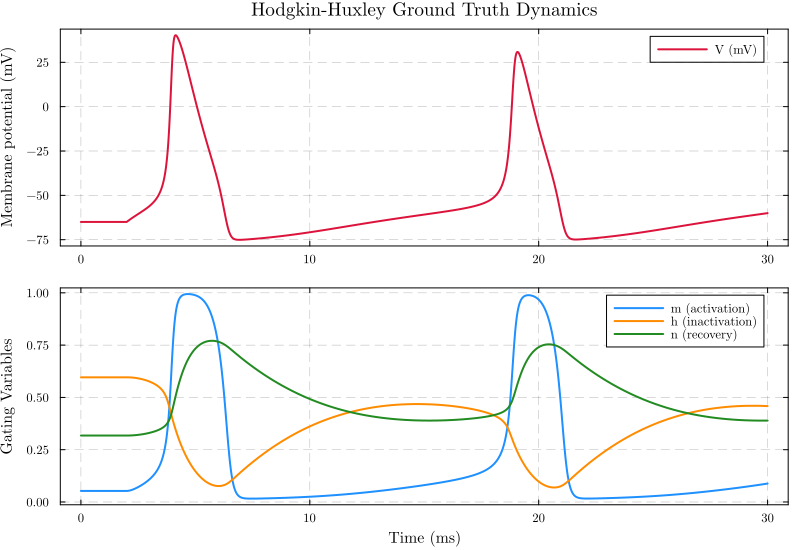

In [23]:
using Plots

# 1. Define color palette
color_V = :crimson
color_m = :dodgerblue
color_h = :darkorange
color_n = :forestgreen

# 2. Configure publication-quality default aesthetics
default(
    fontfamily = "Computer Modern",
    titlefontsize = 12,
    guidefontsize = 10,
    tickfontsize = 8,
    legendfontsize = 8,
    grid = true,
    gridalpha = 0.15,
    gridstyle = :dash,
    frame = :box,
    lw = 2.0
)

p1 = plot(HH_data.t, HH_data.V, color=color_V, label="V (mV)", ylabel="Membrane potential (mV)", title="Hodgkin-Huxley Ground Truth Dynamics", legend = :topright)
p2 = plot(HH_data.t, HH_data.m, color=color_m, label="m (activation)", xlabel="Time (ms)", ylabel="Gating Variables", legend = :topright)
plot!(HH_data.t, HH_data.h, color=color_h, label="h (inactivation)")
plot!(HH_data.t, HH_data.n, color=color_n, label="n (recovery)")

final_plot = plot(p1, p2, layout=grid(2,1, heights=[0.5,0.5]), link=:x, size=(800,550), dpi=100)
display(final_plot)


## Section 3: Biophysical Model Setup

We define the Hodgkin-Huxley parameters, reversal potentials, and rate equations. 

To prevent numerical gradient explosion in the automatic differentiation (AD) backward pass, we guard the singularity divisions in the rate equations $\alpha_m(V)$ and $\alpha_n(V)$ at $V = -40.0\,\text{mV}$ and $V = -55.0\,\text{mV}$ using local **second-order Taylor expansions** when $|V - V_{\text{singularity}}| < 10^{-3}$.


In [24]:
const C_M   = 1.0f0      # Membrane Capacitance (uF/cm^2)
const G_NA  = 120.0f0    # Max Na+ Conductance (mS/cm^2)
const G_K   = 36.0f0     # Max K+ Conductance (mS/cm^2)
const G_L   = 0.3f0      # Leak Conductance (mS/cm^2)
const E_NA  = 50.0f0     # Na+ Reversal Potential (mV)
const E_K   = -77.0f0    # K+ Reversal Potential (mV)
const E_L   = -54.4f0    # Leak Reversal Potential (mV)

# Analytical Resting State at t = 0.0 ms
const V0 = -65.0f0
const M0 = 0.0529f0
const H0 = 0.5961f0
const N0 = 0.3177f0


0.3177f0

In [25]:
# Numerically Stable Rate Equations (Protected near singularities for AD safety)
function alpha_m(V::Real)
    dV = V + 40.0f0
    if abs(dV) < 1.0f-3
        return 1.0f0 + dV / 20.0f0 + (dV^2) / 1200.0f0
    else
        x = -dV / 10.0f0
        return (0.1f0 * dV) / (-expm1(x))
    end
end

function beta_m(V::Real)
    return 4.0f0 * exp(-(V + 65.0f0) / 18.0f0)
end

function alpha_h(V::Real)
    return 0.07f0 * exp(-(V + 65.0f0) / 20.0f0)
end

function beta_h(V::Real)
    return 1.0f0 / (1.0f0 + exp(-(V + 35.0f0) / 10.0f0))
end

function alpha_n(V::Real)
    dV = V + 55.0f0
    if abs(dV) < 1.0f-3
        return 0.1f0 + dV / 200.0f0 + (dV^2) / 12000.0f0
    else
        x = -dV / 10.0f0
        return (0.01f0 * dV) / (-expm1(x))
    end
end

function beta_n(V::Real)
    return 0.125f0 * exp(-(V + 65.0f0) / 80.0f0)
end


beta_n (generic function with 1 method)

In [26]:
# Stimulus current: 10 uA/cm^2 applied between t=2.0ms and t=30.0ms
I_ext(t) = (2.0f0 <= t <= 30.0f0) ? 10.0f0 : 0.0f0

function hh_vector_field(V, m, h, n, t)
    # Ionic Currents
    I_Na = G_NA .* (m .^ 3) .* h .* (V .- E_NA)
    I_K  = G_K  .* (n .^ 4) .* (V .- E_K)
    I_L  = G_L  .* (V .- E_L)
    
    # Differential Derivatives
    dV_dt = (I_ext(t) .- I_Na .- I_K .- I_L) ./ C_M
    dm_dt = alpha_m.(V) .* (1.0f0 .- m) .- beta_m.(V) .* m
    dh_dt = alpha_h.(V) .* (1.0f0 .- h) .- beta_h.(V) .* h
    dn_dt = alpha_n.(V) .* (1.0f0 .- n) .- beta_n.(V) .* n
    
    return dV_dt, dm_dt, dh_dt, dn_dt
end


hh_vector_field (generic function with 1 method)

## Section 4: Training DataLoader Setup

We downcast the variables to `Float32` and slice the dataset into look-ahead sequence windows of length $k=10$. This transforms our inputs into sequence trajectories of shape `(Features, Sequence, TotalBatches)`.


In [27]:
k_fine = 100
k_coarse = 10
k = k_fine
max_idx = size(HH_data, 1) - (k_fine - 1) * 5

t_train = reshape(Float32.(HH_data.t[1:max_idx]), 1, 1, max_idx)

# Construct target trajectories of shape (4, k_fine, max_idx)
gt_tensor = zeros(Float32, 4, k_fine, max_idx)
for s in 1:max_idx
    for γ in 1:k_fine
        row_idx = s + (γ - 1) * 5
        gt_tensor[1, γ, s] = Float32(HH_data.V[row_idx])
        gt_tensor[2, γ, s] = Float32(HH_data.m[row_idx])
        gt_tensor[3, γ, s] = Float32(HH_data.h[row_idx])
        gt_tensor[4, γ, s] = Float32(HH_data.n[row_idx])
    end
end

println("Inputs shape : ", size(t_train))
println("Targets shape: ", size(gt_tensor))

batch_size = 64
data_loader = Flux.DataLoader((t_train, gt_tensor), batchsize=batch_size, shuffle=true)


Inputs shape : (1, 1, 2506)
Targets shape: (4, 100, 2506)


40-element DataLoader(::Tuple{Array{Float32, 3}, Array{Float32, 3}}, shuffle=true, batchsize=64)
  with first element:
  (1×1×64 Array{Float32, 3}, 4×100×64 Array{Float32, 3},)

## Section 5: PINNsFormer Layer Definitions

Here we define the core architecture layers:
1.  `WaveletActivation`: Learnable localized activation using sine and cosine.
2.  `TransformerBlock`: Integrates standard multi-head self-attention with our wavelet activation FFN.
3.  `compute_alignment_matrix` & `align_coarse_path`: Linear interpolation operator that maps the coarse timescale trajectory ($dt=0.5\,\text{ms}$) to match the fine timescale coordinate grid ($dt=0.05\,\text{ms}$).


In [28]:
struct WaveletActivation
    w1::AbstractVector{Float32}
    w2::AbstractVector{Float32}
end
WaveletActivation(d_model::Int) = WaveletActivation(ones(Float32, d_model), ones(Float32, d_model))
# Localized Mexican Hat Wavelet: psi(x) = (1 - x^2) * exp(-x^2 / 2)
(w::WaveletActivation)(x) = (w.w1 .* (1.0f0 .- x.^2) .* exp.(-x.^2 ./ 2.0f0)) .+ (w.w2 .* (1.0f0 .- x.^2) .* exp.(-x.^2 ./ 2.0f0))

struct TransformerBlock
    mha::Flux.MultiHeadAttention
    norm1::Flux.LayerNorm
    ffn::Flux.Chain
    norm2::Flux.LayerNorm
end
Flux.@layer TransformerBlock

function TransformerBlock(d_model::Int, n_heads::Int)
    return TransformerBlock(
        Flux.MultiHeadAttention(d_model, nheads = n_heads),
        Flux.LayerNorm(d_model),
        Flux.Chain(Flux.Dense(d_model => d_model), WaveletActivation(d_model)),
        Flux.LayerNorm(d_model)
    )
end

function (t::TransformerBlock)(x)
    seq_len = size(x, 2)
    # Causal lower-triangular mask to prevent future-to-past information leakage
    causal_mask = LinearAlgebra.tril(ones(Bool, seq_len, seq_len))
    attn_out = t.mha(x, x, x; mask=causal_mask)[1]
    x = t.norm1(x .+ attn_out)
    ffn_out = t.ffn(x)
    x = t.norm2(x .+ ffn_out)
    return x
end


In [29]:
function compute_alignment_matrix(k_fine::Int, k_coarse::Int, dt_fine::Float32, dt_coarse::Float32)
    M = zeros(Float32, k_fine, k_coarse)
    for i in 1:k_fine
        t_target = (i - 1) * dt_fine
        val = (t_target / dt_coarse) + 1.0f0
        low_idx = clamp(floor(Int, val), 1, k_coarse)
        high_idx = clamp(ceil(Int, val), 1, k_coarse)
        if low_idx == high_idx
            M[i, low_idx] = 1.0f0
        else
            rem = val - low_idx
            M[i, low_idx] = 1.0f0 - rem
            M[i, high_idx] = rem
        end
    end
    return M
end

function align_coarse_path(H_coarse::AbstractArray, M_align::AbstractArray)
    d_model, k_coarse, B = size(H_coarse)
    return dropdims(sum(reshape(H_coarse, d_model, 1, k_coarse, B) .* M_align, dims=3), dims=3)
end


align_coarse_path (generic function with 1 method)

## Section 6: Main PINNsFormer Struct Definition

We define the complete hierarchical parallel timescales model. The coarse and fine timeline representations are projected and aligned before summing, then passed to the prediction head.


In [30]:
struct PINNsFormer
    fine_proj::Flux.Dense
    coarse_proj::Flux.Dense
    pe_fine::Array{Float32, 3}
    pe_coarse::Array{Float32, 3}
    wavelet::WaveletActivation
    fine_encoder::TransformerBlock
    coarse_encoder::TransformerBlock
    M_align::Array{Float32, 4}
    head::Flux.Dense
end
Flux.@layer PINNsFormer

function PINNsFormer(d_model::Int=32, k_fine::Int=100, k_coarse::Int=10, n_heads::Int=4)
    pe_f = zeros(Float32, d_model, k_fine)
    for j in 1:k_fine
        for i in 0:(div(d_model, 2) - 1)
            denom = 10000.0f0^(2f0 * i / d_model)
            pe_f[2i+1, j] = sin((j - 1) / denom)
            pe_f[2i+2, j] = cos((j - 1) / denom)
        end
    end
    pe_fine_3d = reshape(pe_f, d_model, k_fine, 1)
    
    pe_c = zeros(Float32, d_model, k_coarse)
    for j in 1:k_coarse
        for i in 0:(div(d_model, 2) - 1)
            denom = 10000.0f0^(2f0 * i / d_model)
            pe_c[2i+1, j] = sin((j - 1) / denom)
            pe_c[2i+2, j] = cos((j - 1) / denom)
        end
    end
    pe_coarse_3d = reshape(pe_c, d_model, k_coarse, 1)
    
    M = compute_alignment_matrix(k_fine, k_coarse, 0.05f0, 0.5f0)
    M_align_4d = reshape(M, 1, k_fine, k_coarse, 1)
    
    return PINNsFormer(
        Flux.Dense(1 => d_model),
        Flux.Dense(1 => d_model),
        pe_fine_3d,
        pe_coarse_3d,
        WaveletActivation(d_model),
        TransformerBlock(d_model, n_heads),
        TransformerBlock(d_model, n_heads),
        M_align_4d,
        Flux.Dense(d_model => 4)
    )
end


PINNsFormer

In [31]:
function generate_trajectories(t_batch; k_fine=100, k_coarse=10, dt_fine=0.05f0, dt_coarse=0.5f0)
    if eltype(t_batch) <: ForwardDiff.Dual
        Batch = size(t_batch, 3)
        # Functional array comprehension (100% non-mutating, no setindex!)
        T_fine = [
            ForwardDiff.Dual{Nothing, Float32, k_fine}(
                ForwardDiff.value(t_batch[1, 1, b]) + (i - 1) * dt_fine,
                ntuple(j -> (j == i ? 1.0f0 : 0.0f0), k_fine)
            ) for c in 1:1, i in 1:k_fine, b in 1:Batch
        ]
        T_coarse = [
            ForwardDiff.Dual{Nothing, Float32, k_fine}(
                ForwardDiff.value(t_batch[1, 1, b]) + (j - 1) * dt_coarse,
                ntuple(i -> 0.0f0, k_fine)
            ) for c in 1:1, j in 1:k_coarse, b in 1:Batch
        ]
        return T_fine, T_coarse
    else
        steps_fine = reshape(Float32.(0:(k_fine-1)), 1, k_fine, 1)
        steps_coarse = reshape(Float32.(0:(k_coarse-1)), 1, k_coarse, 1)
        return t_batch .+ (steps_fine .* dt_fine), t_batch .+ (steps_coarse .* dt_coarse)
    end
end

Zygote.@adjoint function generate_trajectories(t_batch; k_fine=100, k_coarse=10, dt_fine=0.05f0, dt_coarse=0.5f0)
    return generate_trajectories(t_batch; k_fine=k_fine, k_coarse=k_coarse), Δ -> (nothing,)
end

function (m::PINNsFormer)(t_batch)
    k_fine = size(m.pe_fine, 2)
    k_coarse = size(m.pe_coarse, 2)
    T_fine, T_coarse = generate_trajectories(t_batch; k_fine=k_fine, k_coarse=k_coarse)
    X_fine = m.fine_proj(T_fine) .+ m.pe_fine
    X_coarse = m.coarse_proj(T_coarse) .+ m.pe_coarse
    
    Z_fine = m.wavelet(X_fine)
    Z_coarse = m.wavelet(X_coarse)
    
    H_fine = m.fine_encoder(Z_fine)
    H_coarse = m.coarse_encoder(Z_coarse)
    
    H_coarse_aligned = align_coarse_path(H_coarse, m.M_align)
    H_unified = H_fine .+ H_coarse_aligned
    raw_out = m.head(H_unified)
    
    # Enforce physical bounds control
    V = -20.0f0 .+ 70.0f0 .* tanh.(raw_out[1:1, :, :])
    gating = NNlib.sigmoid.(raw_out[2:4, :, :])
    return cat(V, gating; dims=1)
end


## Section 7: Loss Infrastructure

Here we define the composite causal loss setup:
1.  `compute_ad_derivatives`: Approximates exact derivatives using automatic differentiation (AD).
2.  `compute_physics_residuals`: Evaluates biophysical system residues.
3.  `compute_boundary_and_data_losses`: Enforces resting initial conditions and supervised data matching.
4.  `update_ntk_weights_ema!`: Balance loss component gradients trace using Neural Tangent Kernel EMA scaling.
5.  `total_loss_causal`: Aggregates residuals using a temporal causality mask along the look-ahead steps.


In [32]:
# Continuous trajectory AD derivatives & physics residuals
Zygote.@adjoint function NNlib.dropout(rng::Random.AbstractRNG, x::AbstractArray{<:ForwardDiff.Dual}, p; kwargs...)
    return x, Δ -> (nothing, Δ, nothing, nothing)
end

function extract_diagonal_partials(X_dual::Array{ForwardDiff.Dual{T, F, N}, 3}) where {T, F, N}
    return [X_dual[c, i, b].partials[i] for c in 1:4, i in 1:size(X_dual, 2), b in 1:size(X_dual, 3)]
end

Zygote.@adjoint function extract_diagonal_partials(X_dual::Array{ForwardDiff.Dual{T, F, N}, 3}) where {T, F, N}
    dX_dt = extract_diagonal_partials(X_dual)
    k_steps = size(X_dual, 2)
    Batch = size(X_dual, 3)
    function back(Δ)
        dX_dual = Array{ForwardDiff.Dual{T, F, N}, 3}(undef, 4, k_steps, Batch)
        for b in 1:Batch, i in 1:k_steps, c in 1:4
            p = ntuple(j -> (j == i ? Δ[c, i, b] : 0.0f0), k_steps)
            dX_dual[c, i, b] = ForwardDiff.Dual{T, F, N}(0.0f0, ForwardDiff.Partials(p))
        end
        return (dX_dual,)
    end
    return dX_dt, back
end

function make_dual_inputs(t, k_steps)
    T = Nothing
    F = Float32
    N = k_steps
    Batch = size(t, 3)
    t_dual = Array{ForwardDiff.Dual{T, F, N}, 3}(undef, 1, 1, Batch)
    for b in 1:Batch
        p = ntuple(j -> 0.0f0, k_steps)
        t_dual[1, 1, b] = ForwardDiff.Dual{T, F, N}(t[1, 1, b], ForwardDiff.Partials(p))
    end
    return t_dual
end

Zygote.@adjoint function make_dual_inputs(t, k_steps)
    return make_dual_inputs(t, k_steps), Δ -> (nothing, nothing)
end

function compute_ad_derivatives(model, t_tensor)
    k_steps = size(model.pe_fine, 2)
    t_dual = make_dual_inputs(t_tensor, k_steps)
    X_dual = model(t_dual)
    X_pred = [X_dual[c, i, b].value for c in 1:4, i in 1:k_steps, b in 1:size(t_tensor, 3)]
    dX_dt = extract_diagonal_partials(X_dual)
    return X_pred, dX_dt
end

function compute_physics_residuals(X_pred, dX_pred_dt, I_ext_value=10.0f0)
    V = X_pred[1, :, :]
    m = X_pred[2, :, :]
    h = X_pred[3, :, :]
    n = X_pred[4, :, :]
    
    I_Na = G_NA .* (m .^ 3) .* h .* (V .- E_NA)
    I_K  = G_K  .* (n .^ 4) .* (V .- E_K)
    I_L  = G_L  .* (V .- E_L)
    
    f_V = (I_ext_value .- I_Na .- I_K .- I_L) ./ C_M
    f_m = alpha_m.(V) .* (1.0f0 .- m) .- beta_m.(V) .* m
    f_h = alpha_h.(V) .* (1.0f0 .- h) .- beta_h.(V) .* h
    f_n = alpha_n.(V) .* (1.0f0 .- n) .- beta_n.(V) .* n
    
    # Scale-Aware Multiscale Normalization: Divide voltage residual by 100.0f0 mV
    R_V = (dX_pred_dt[1, :, :] .- f_V) ./ 100.0f0
    R_m = dX_pred_dt[2, :, :] .- f_m
    R_h = dX_pred_dt[3, :, :] .- f_h
    R_n = dX_pred_dt[4, :, :] .- f_n
    
    L_RV = mean(abs2, R_V)
    L_Rm = mean(abs2, R_m)
    L_Rh = mean(abs2, R_h)
    L_Rn = mean(abs2, R_n)
    
    return L_RV, L_Rm, L_Rh, L_Rn
end


compute_physics_residuals (generic function with 2 methods)

In [33]:
const IC_GROUND_TRUTH = Float32[-65.0, 0.0529, 0.5961, 0.3177]

function compute_boundary_and_data_losses(model, X_pred, ground_truth_batch)
    t_zero = zeros(Float32, 1, 1, 1)
    X_zero = model(t_zero)[:, 1, 1]
    L_ic = mean(abs2, X_zero .- IC_GROUND_TRUTH)
    L_data = mean(abs2, X_pred .- ground_truth_batch)
    return L_ic, L_data
end

mutable struct NTKState
    RV::Float32
    Rm::Float32
    Rh::Float32
    Rn::Float32
    ic::Float32
    data::Float32
end

function update_ntk_weights_ema!(λ_state, model, batch_t, batch_data, I_ext; α=0.1f0)
    _, gs_RV   = Flux.withgradient(m -> compute_physics_residuals(compute_ad_derivatives(m, batch_t)[1], compute_ad_derivatives(m, batch_t)[2], I_ext)[1], model)
    _, gs_Rm   = Flux.withgradient(m -> compute_physics_residuals(compute_ad_derivatives(m, batch_t)[1], compute_ad_derivatives(m, batch_t)[2], I_ext)[2], model)
    _, gs_Rh   = Flux.withgradient(m -> compute_physics_residuals(compute_ad_derivatives(m, batch_t)[1], compute_ad_derivatives(m, batch_t)[2], I_ext)[3], model)
    _, gs_Rn   = Flux.withgradient(m -> compute_physics_residuals(compute_ad_derivatives(m, batch_t)[1], compute_ad_derivatives(m, batch_t)[2], I_ext)[4], model)
    _, gs_ic   = Flux.withgradient(m -> compute_boundary_and_data_losses(m, m(batch_t), batch_data)[1], model)
    _, gs_data = Flux.withgradient(m -> compute_boundary_and_data_losses(m, m(batch_t), batch_data)[2], model)
    
    function trace_norm(gs)
        c_g = clean_gradient(gs[1])
        flat_g, _ = Flux.destructure(c_g)
        return sum(abs2, flat_g) + 1f-8
    end
    
    tr_RV   = trace_norm(gs_RV)
    tr_Rm   = trace_norm(gs_Rm)
    tr_Rh   = trace_norm(gs_Rh)
    tr_Rn   = trace_norm(gs_Rn)
    tr_ic   = trace_norm(gs_ic)
    tr_data = trace_norm(gs_data)
    
    mean_target = (tr_RV + tr_Rm + tr_Rh + tr_Rn + tr_ic + tr_data) / 6.0f0
    
    λ_hat_RV   = mean_target / tr_RV
    λ_hat_Rm   = mean_target / tr_Rm
    λ_hat_Rh   = mean_target / tr_Rh
    λ_hat_Rn   = mean_target / tr_Rn
    λ_hat_ic   = mean_target / tr_ic
    λ_hat_data = mean_target / tr_data
    
    sum_λ = λ_hat_RV + λ_hat_Rm + λ_hat_Rh + λ_hat_Rn + λ_hat_ic + λ_hat_data
    λ_hat_RV   = 6.0f0 * λ_hat_RV   / sum_λ
    λ_hat_Rm   = 6.0f0 * λ_hat_Rm   / sum_λ
    λ_hat_Rh   = 6.0f0 * λ_hat_Rh   / sum_λ
    λ_hat_Rn   = 6.0f0 * λ_hat_Rn   / sum_λ
    λ_hat_ic   = 6.0f0 * λ_hat_ic   / sum_λ
    λ_hat_data = 6.0f0 * λ_hat_data / sum_λ
    
    λ_state.RV   = (1.0f0 - α) * λ_state.RV   + α * λ_hat_RV
    λ_state.Rm   = (1.0f0 - α) * λ_state.Rm   + α * λ_hat_Rm
    λ_state.Rh   = (1.0f0 - α) * λ_state.Rh   + α * λ_hat_Rh
    λ_state.Rn   = (1.0f0 - α) * λ_state.Rn   + α * λ_hat_Rn
    λ_state.ic   = (1.0f0 - α) * λ_state.ic   + α * λ_hat_ic
    λ_state.data = (1.0f0 - α) * λ_state.data + α * λ_hat_data
    
    return λ_state
end


update_ntk_weights_ema! (generic function with 1 method)

In [34]:
function clean_gradient(g)
    if g isa ForwardDiff.Dual
        return sum(ForwardDiff.partials(g))
    elseif g isa AbstractArray
        return map(clean_gradient, g)
    elseif repr(typeof(g)) == "ChainRulesCore.NoTangent" || g === nothing
        return g
    elseif hasproperty(g, :backing)
        return clean_gradient(g.backing)
    elseif g isa NamedTuple
        return map(clean_gradient, g)
    elseif g isa Tuple
        return map(clean_gradient, g)
    else
        return g
    end
end

function total_loss_causal(model, batch_t, batch_data, λ, I_ext; ϵ=1.0f0)
    X_pred, dX_dt = compute_ad_derivatives(model, batch_t)
    
    V = X_pred[1, :, :]
    m = X_pred[2, :, :]
    h = X_pred[3, :, :]
    n = X_pred[4, :, :]
    
    I_Na = G_NA .* (m.^3) .* h .* (V .- E_NA)
    I_K  = G_K  .* (n.^4) .* (V .- E_K)
    I_L  = G_L  .* (V .- E_L)
    
    f_V = (I_ext .- I_Na .- I_K .- I_L) ./ C_M
    f_m = alpha_m.(V) .* (1.0f0 .- m) .- beta_m.(V) .* m
    f_h = alpha_h.(V) .* (1.0f0 .- h) .- beta_h.(V) .* h
    f_n = alpha_n.(V) .* (1.0f0 .- n) .- beta_n.(V) .* n
    
    # Scale-Aware Multiscale Normalization for V residual
    R_V = ((dX_dt[1, :, :] .- f_V) ./ 100.0f0).^2
    R_m = (dX_dt[2, :, :] .- f_m).^2
    R_h = (dX_dt[3, :, :] .- f_h).^2
    R_n = (dX_dt[4, :, :] .- f_n).^2
    
    L_steps = vec(mean(λ.RV .* R_V .+ λ.Rm .* R_m .+ λ.Rh .* R_h .+ λ.Rn .* R_n, dims=2))
    
    cum_losses = cumsum(L_steps)
    accumulated_losses = cat(0.0f0, cum_losses[1:end-1]; dims=1)
    w = exp.(-ϵ .* accumulated_losses)
    
    L_phys_total = sum(w .* L_steps)
    L_ic, L_data = compute_boundary_and_data_losses(model, X_pred, batch_data)
    
    return L_phys_total + (λ.ic * L_ic) + (λ.data * L_data)
end


total_loss_causal (generic function with 1 method)

## Section 8: Optimization and Training Pipeline

We implement the multi-stage training pipeline:
1.  **Stage 1a (Adam, LR = 1e-3, NTK interval = 50)**: High learning rate for global exploration. NTK weights updated lazily.
2.  **Stage 1b (Adam, LR = 1e-4, NTK interval = 10)**: Lower learning rate for fine-tuning. NTK weights updated more frequently to stabilize stiffness curves.
3.  **Stage 2 (L-BFGS quasi-Newton)**: Employs second-order curvature gradients to fit the fast action potential upstroke with high numerical precision.
4.  **Serialization Checkpoints**: Saves periodic models (`trained_model_checkpoint_epoch_X.jls`) and stage completions to disk.


In [35]:
using Serialization

function train_phase3_pipeline!(model, dataloader; adam_epochs_1=1000, adam_epochs_2=1000, lbfgs_epochs=500)
    I_ext = 10.0f0
    λ_state = NTKState(1.0f0, 1.0f0, 1.0f0, 1.0f0, 1.0f0, 1.0f0)
    
    loss_history = Float32[]
    loss_history_RV = Float32[]
    loss_history_Rm = Float32[]
    loss_history_Rh = Float32[]
    loss_history_Rn = Float32[]
    causal_weights_log = Vector{Float32}[]
    causal_epochs_log = Int[]
    
    # --- STAGE 1a: Adam Optimizer (Global Exploration, High LR=1e-3) ---
    println("\n=== STAGE 1a: Starting Adam Stage 1 (epochs 1 to $adam_epochs_1, LR=1e-3, NTK interval=50) ===")
    opt_adam_1 = Flux.setup(Flux.Adam(1e-3), model)
    
    for epoch in 1:adam_epochs_1
        # Causal Parameter Curriculum Schedule: linear warm-up from 0 up to 0.5f0
        ϵ_curr = min(0.5f0, 1.0f-4 * Float32(epoch))
        
        total_epoch_loss = 0.0f0
        if (epoch - 1) % 50 == 0
            sample_t, sample_data = first(dataloader)
            update_ntk_weights_ema!(λ_state, model, sample_t, sample_data, I_ext; α=0.1f0)
        end
        
        for (batch_t, batch_data) in dataloader
            loss_val, grads = Flux.withgradient(m -> total_loss_causal(m, batch_t, batch_data, λ_state, I_ext; ϵ=ϵ_curr), model)
            clean_grads = clean_gradient(grads[1])
            Flux.update!(opt_adam_1, model, clean_grads)
            total_epoch_loss += loss_val
        end
        push!(loss_history, total_epoch_loss)
        
        if epoch % 100 == 0
            checkpoint_path = "trained_model_checkpoint_epoch_$(epoch).jls"
            serialize(checkpoint_path, model)
            println("Saved checkpoint at epoch $(epoch) to $(checkpoint_path)")
        end
        
        sample_t, sample_data = first(dataloader)
        X_pred, dX_dt = compute_ad_derivatives(model, sample_t)
        L_RV_val, L_Rm_val, L_Rh_val, L_Rn_val = compute_physics_residuals(X_pred, dX_dt, I_ext)
        push!(loss_history_RV, L_RV_val)
        push!(loss_history_Rm, L_Rm_val)
        push!(loss_history_Rh, L_Rh_val)
        push!(loss_history_Rn, L_Rn_val)
        
        if epoch % 50 == 0 || epoch == 1
            k = size(X_pred, 2)
            L_steps = zeros(Float32, k)
            for i in 1:k
                L_steps[i] = mean(λ_state.RV * (((dX_dt[1, i, :] .- (I_ext .- (G_NA .* (X_pred[2, i, :].^3) .* X_pred[3, i, :] .* (X_pred[1, i, :] .- E_NA) .+ G_K .* (X_pred[4, i, :].^4) .* (X_pred[1, i, :] .- E_K) .+ G_L .* (X_pred[1, i, :] .- E_L)) ./ C_M)) ./ 100.0f0).^2) .+
                                  λ_state.Rm * ((dX_dt[2, i, :] .- (alpha_m.(X_pred[1, i, :]) .* (1.0f0 .- X_pred[2, i, :]) .- beta_m.(X_pred[1, i, :]) .* X_pred[2, i, :])).^2) .+
                                  λ_state.Rh * ((dX_dt[3, i, :] .- (alpha_h.(X_pred[1, i, :]) .* (1.0f0 .- X_pred[3, i, :]) .- beta_h.(X_pred[1, i, :]) .* X_pred[3, i, :])).^2) .+
                                  λ_state.Rn * ((dX_dt[4, i, :] .- (alpha_n.(X_pred[1, i, :]) .* (1.0f0 .- X_pred[4, i, :]) .- beta_n.(X_pred[1, i, :]) .* X_pred[4, i, :])).^2))
            end
            w = zeros(Float32, k)
            w[1] = 1.0f0
            accumulated_loss = 0.0f0
            for i in 2:k
                accumulated_loss += L_steps[i-1]
                w[i] = exp(-ϵ_curr * accumulated_loss)
            end
            push!(causal_weights_log, w)
            push!(causal_epochs_log, epoch)
            
            println("Adam Stage 1 Epoch [$epoch / $adam_epochs_1] (ϵ = $(round(ϵ_curr, digits=4))) - Causal Loss: ", round(total_epoch_loss, digits=6))
        end
    end
    
    # --- STAGE 1b: Adam Optimizer (Fine-Tuning, Low LR=1e-4) ---
    println("\n=== STAGE 1b: Starting Adam Stage 2 (epochs 1 to $adam_epochs_2, LR=1e-4, NTK interval=10) ===")
    opt_adam_2 = Flux.setup(Flux.Adam(1e-4), model)
    
    for epoch in 1:adam_epochs_2
        total_epoch_idx = adam_epochs_1 + epoch
        ϵ_curr = min(0.5f0, 1.0f-4 * Float32(total_epoch_idx))
        
        total_epoch_loss = 0.0f0
        if (epoch - 1) % 10 == 0
            sample_t, sample_data = first(dataloader)
            update_ntk_weights_ema!(λ_state, model, sample_t, sample_data, I_ext; α=0.1f0)
        end
        
        for (batch_t, batch_data) in dataloader
            loss_val, grads = Flux.withgradient(m -> total_loss_causal(m, batch_t, batch_data, λ_state, I_ext; ϵ=ϵ_curr), model)
            clean_grads = clean_gradient(grads[1])
            Flux.update!(opt_adam_2, model, clean_grads)
            total_epoch_loss += loss_val
        end
        
        push!(loss_history, total_epoch_loss)
        
        if total_epoch_idx % 500 == 0
            checkpoint_path = "trained_model_checkpoint_epoch_$(total_epoch_idx).jls"
            serialize(checkpoint_path, model)
            println("Saved checkpoint at epoch $(total_epoch_idx) to $(checkpoint_path)")
        end
        
        sample_t, sample_data = first(dataloader)
        X_pred, dX_dt = compute_ad_derivatives(model, sample_t)
        L_RV_val, L_Rm_val, L_Rh_val, L_Rn_val = compute_physics_residuals(X_pred, dX_dt, I_ext)
        push!(loss_history_RV, L_RV_val)
        push!(loss_history_Rm, L_Rm_val)
        push!(loss_history_Rh, L_Rh_val)
        push!(loss_history_Rn, L_Rn_val)
        
        if total_epoch_idx % 50 == 0 || epoch == 1
            k = size(X_pred, 2)
            L_steps = zeros(Float32, k)
            for i in 1:k
                L_steps[i] = mean(λ_state.RV * (((dX_dt[1, i, :] .- (I_ext .- (G_NA .* (X_pred[2, i, :].^3) .* X_pred[3, i, :] .* (X_pred[1, i, :] .- E_NA) .+ G_K .* (X_pred[4, i, :].^4) .* (X_pred[1, i, :] .- E_K) .+ G_L .* (X_pred[1, i, :] .- E_L)) ./ C_M)) ./ 100.0f0).^2) .+
                                  λ_state.Rm * ((dX_dt[2, i, :] .- (alpha_m.(X_pred[1, i, :]) .* (1.0f0 .- X_pred[2, i, :]) .- beta_m.(X_pred[1, i, :]) .* X_pred[2, i, :])).^2) .+
                                  λ_state.Rh * ((dX_dt[3, i, :] .- (alpha_h.(X_pred[1, i, :]) .* (1.0f0 .- X_pred[3, i, :]) .- beta_h.(X_pred[1, i, :]) .* X_pred[3, i, :])).^2) .+
                                  λ_state.Rn * ((dX_dt[4, i, :] .- (alpha_n.(X_pred[1, i, :]) .* (1.0f0 .- X_pred[4, i, :]) .- beta_n.(X_pred[1, i, :]) .* X_pred[4, i, :])).^2))
            end
            w = zeros(Float32, k)
            w[1] = 1.0f0
            accumulated_loss = 0.0f0
            for i in 2:k
                accumulated_loss += L_steps[i-1]
                w[i] = exp(-ϵ_curr * accumulated_loss)
            end
            push!(causal_weights_log, w)
            push!(causal_epochs_log, total_epoch_idx)
            
            println("Adam Stage 2 Epoch [$total_epoch_idx / $(adam_epochs_1 + adam_epochs_2)] (ϵ = $(round(ϵ_curr, digits=4))) - Causal Loss: ", round(total_epoch_loss, digits=6))
        end
    end
    
    # --- STAGE 2: L-BFGS Optimizer (Local Curve-Fitting) ---
    println("\n=== STAGE 2: Transitioning to L-BFGS Optimization ($lbfgs_epochs Iterations) ===")
    serialize("trained_model_post_adam.jls", model)
    println("Saved post-Adam model checkpoint.")
    
    flat_params, re = Flux.destructure(model)
    sample_t, sample_data = first(dataloader)
    
    function lbfgs_objective(p)
        l = total_loss_causal(re(p), sample_t, sample_data, λ_state, I_ext; ϵ=0.5f0)
        push!(loss_history, l)
        X_pred, dX_dt = compute_ad_derivatives(re(p), sample_t)
        L_RV_val, L_Rm_val, L_Rh_val, L_Rn_val = compute_physics_residuals(X_pred, dX_dt, I_ext)
        push!(loss_history_RV, L_RV_val)
        push!(loss_history_Rm, L_Rm_val)
        push!(loss_history_Rh, L_Rh_val)
        push!(loss_history_Rn, L_Rn_val)
        return l
    end
    
    function lbfgs_gradient!(g, p)
        _, grads = Flux.withgradient(m -> total_loss_causal(m, sample_t, sample_data, λ_state, I_ext; ϵ=0.5f0), re(p))
        clean_grads = clean_gradient(grads[1])
        flat_grads, _ = Flux.destructure(clean_grads)
        g .= flat_grads
    end
    
    iter_count = Ref(0)
    function lbfgs_callback(state)
        iter_count[] += 1
        if iter_count[] % 50 == 0 || iter_count[] == 1
            println("L-BFGS Iteration [$(iter_count[]) / $lbfgs_epochs] - Causal Loss: ", round(state.f_x, digits=6))
        end
        return false
    end
    
    opt_res = Optim.optimize(
        lbfgs_objective,
        lbfgs_gradient!,
        flat_params,
        Optim.LBFGS(m=10),
        Optim.Options(iterations=lbfgs_epochs, show_trace=false, callback=lbfgs_callback)
    )
    
    final_model = re(opt_res.minimizer)
    
    history = (
        total = loss_history,
        RV = loss_history_RV,
        Rm = loss_history_Rm,
        Rh = loss_history_Rh,
        Rn = loss_history_Rn,
        causal_weights = causal_weights_log,
        causal_epochs = causal_epochs_log
    )
    
    return final_model, history
end


train_phase3_pipeline! (generic function with 1 method)

## Section 9: Model Training Execution

We instantiate the PINNsFormer network model (32 hidden dimensions, $k=10$ look-ahead sequence length, 4 heads self-attention) and run the multi-stage training pipeline.


In [ ]:
using Random
Random.seed!(42)  # Enforce deterministic initialization

p_model = PINNsFormer(32, 100, 10, 4)

println("Starting full 3-phase PINNsFormer training pipeline...")
trained_model, history = train_phase3_pipeline!(p_model, data_loader; adam_epochs_1=1000, adam_epochs_2=1000, lbfgs_epochs=500)


Starting full 3-phase PINNsFormer training pipeline...


## Section 10: Convergence History Visualizations

We plot the convergence results:
1.  **Plot 1**: Dual-stage logarithmic causal loss history.
2.  **Plot 2**: Component-wise residual decomposition history (individual channels: $V, m, h, n$).
3.  **Plot 3**: Causal weight propagation training heatmap showing how attention weights propagate across look-ahead steps over epochs.


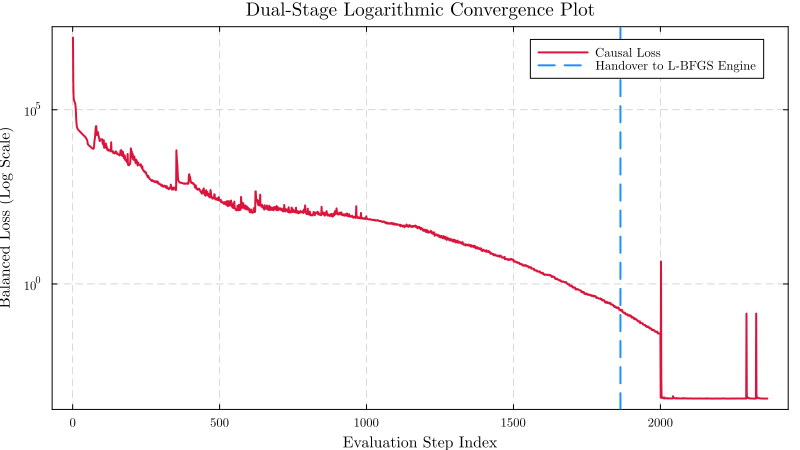

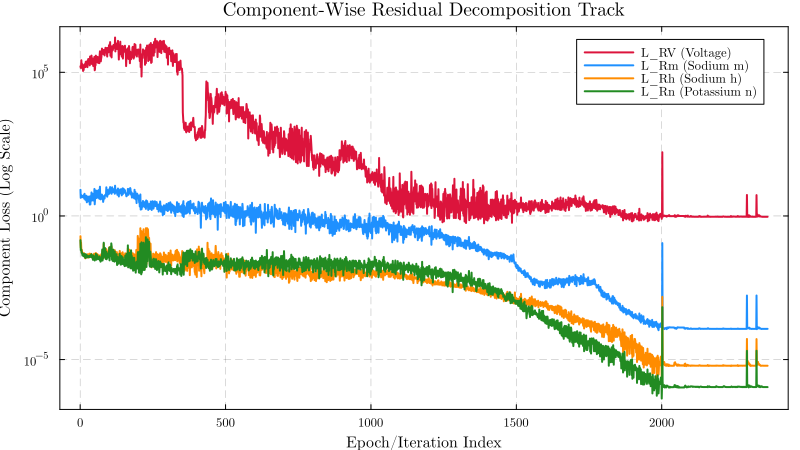

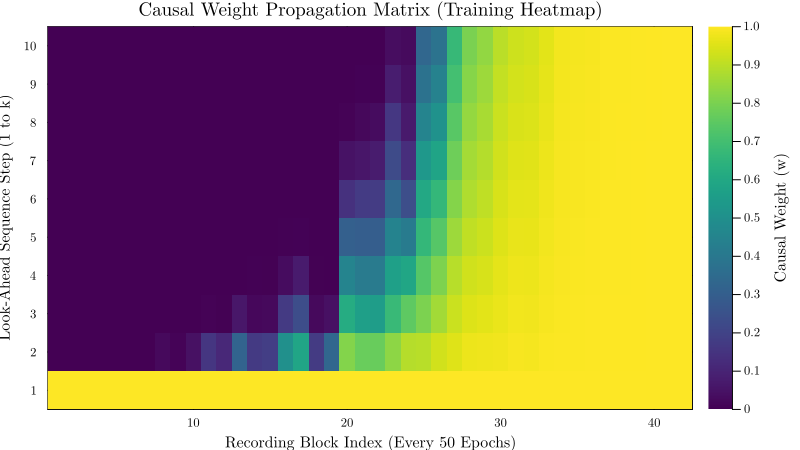

In [ ]:
using Plots

p1 = plot(
    history.total,
    yscale = :log10,
    color = :crimson,
    xlabel = "Evaluation Step Index",
    ylabel = "Balanced Loss (Log Scale)",
    title = "Dual-Stage Logarithmic Convergence Plot",
    label = "Causal Loss",
    legend = :topright,
    size = (800, 450)
)
vline!([length(history.total) - 500], color=:dodgerblue, linestyle=:dash, label="Handover to L-BFGS Engine")
display(p1)

p2 = plot(
    yscale = :log10, 
    xlabel = "Epoch/Iteration Index", 
    ylabel = "Component Loss (Log Scale)", 
    title = "Component-Wise Residual Decomposition Track", 
    size = (800, 450), 
    legend = :topright
)
plot!(history.RV, color=:crimson, label="L_RV (Voltage)")
plot!(history.Rm, color=:dodgerblue, label="L_Rm (Sodium m)")
plot!(history.Rh, color=:darkorange, label="L_Rh (Sodium h)")
plot!(history.Rn, color=:forestgreen, label="L_Rn (Potassium n)")
display(p2)

k_val = size(history.causal_weights[1], 1)
num_recordings = length(history.causal_weights)
W_matrix = zeros(Float32, k_val, num_recordings)
for col in 1:num_recordings
    W_matrix[:, col] = history.causal_weights[col]
end

p3 = heatmap(
    1:num_recordings,
    1:k_val,
    W_matrix,
    color = :viridis,
    yflip = false,
    xlabel = "Recording Block Index (Every 50 Epochs)",
    ylabel = "Look-Ahead Sequence Step (1 to k)",
    title = "Causal Weight Propagation Matrix (Training Heatmap)",
    colorbar_title = "Causal Weight (w)",
    size = (800, 450)
)
display(p3)


## Section 11: Validation Dashboard (Predictions vs Ground Truth)

We evaluate the fully trained model on the full continuous time axis and audit the predictions against the exact biophysical trajectories computed by the numerical solver.


Extracting model trajectories for visual audit...


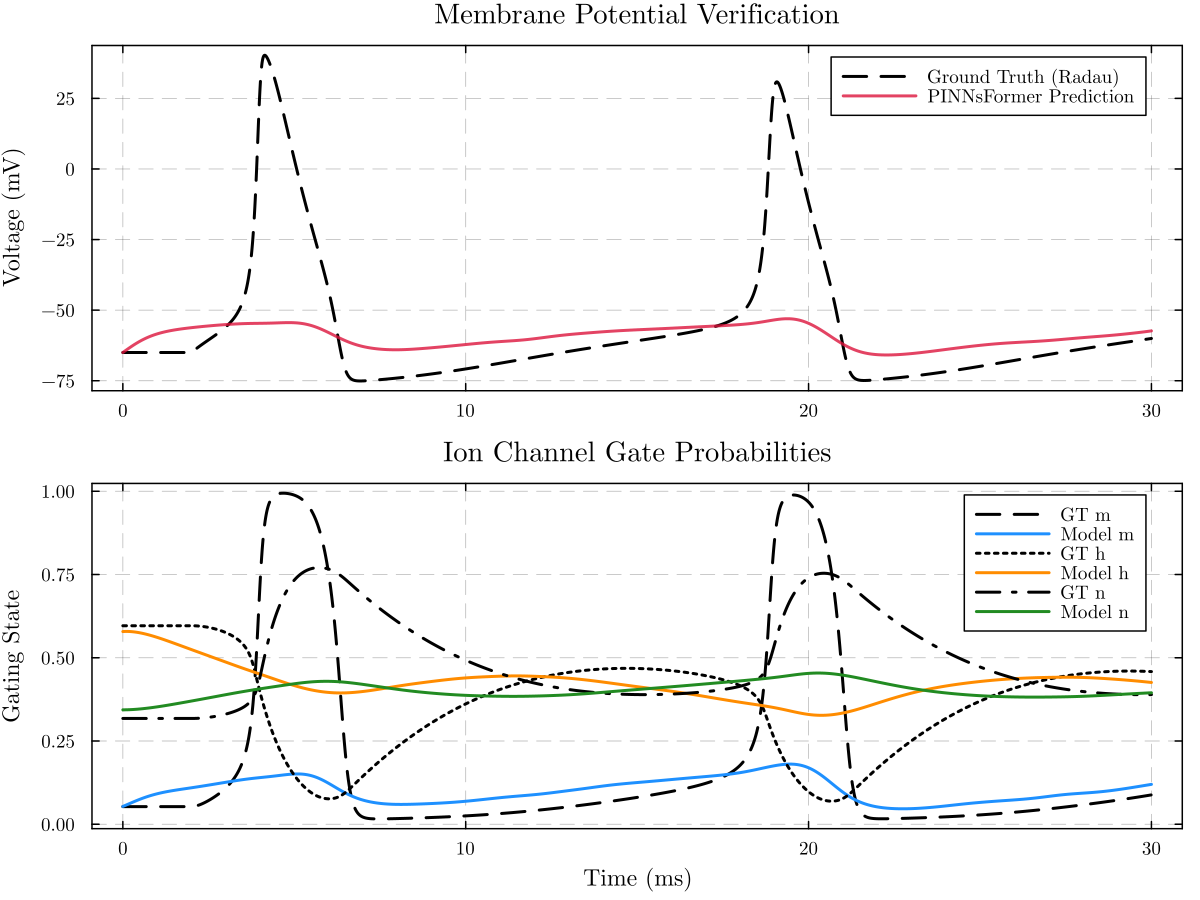

In [ ]:
using Plots

println("Extracting model trajectories for visual audit...")
t_full_tensor = reshape(Float32.(HH_data.t), 1, 1, length(HH_data.t))
full_prediction = trained_model(t_full_tensor)

V_pred = full_prediction[1, 1, :]
m_pred = full_prediction[2, 1, :]
h_pred = full_prediction[3, 1, :]
n_pred = full_prediction[4, 1, :]

p_voltage = plot(HH_data.t, HH_data.V, color=:black, line=:dash, label="Ground Truth (Radau)")
plot!(HH_data.t, V_pred, color=:crimson, alpha=0.8, label="PINNsFormer Prediction")
title!("Membrane Potential Verification")
ylabel!("Voltage (mV)")

p_gates = plot(HH_data.t, HH_data.m, color=:black, line=:dash, label="GT m")
plot!(HH_data.t, m_pred, color=:dodgerblue, label="Model m")
plot!(HH_data.t, HH_data.h, color=:black, line=:dot, label="GT h")
plot!(HH_data.t, h_pred, color=:darkorange, label="Model h")
plot!(HH_data.t, HH_data.n, color=:black, line=:dashdot, label="GT n")
plot!(HH_data.t, n_pred, color=:forestgreen, label="Model n")
title!("Ion Channel Gate Probabilities")
xlabel!("Time (ms)")
ylabel!("Gating State")

verification_dashboard = plot(
    p_voltage, p_gates, 
    layout = grid(2, 1, heights=[0.5, 0.5]),
    link = :x,
    size = (800, 600),
    dpi = 150
)
display(verification_dashboard)


## Section 12: Model Persistence

We serialize and save the final trained model parameters to a `.jls` file using native `Serialization`.


In [ ]:
using Serialization

model_save_path = "trained_pinnsformer_model.jls"
serialize(model_save_path, trained_model)
println("Successfully saved the trained model parameters to: ", model_save_path)


Successfully saved the trained model parameters to: trained_pinnsformer_model.jls
